In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import os

# --- CONFIGURATION ---
radiomics_file = '../Results/final_radiomics_merged.csv'
output_dir = '../Results/Final_Figures/'
os.makedirs(output_dir, exist_ok=True)

print("--- STARTING XAI DOMAIN AUDIT ---")

# 1. Load Data
if not os.path.exists(radiomics_file):
    print("Error: Merged radiomics file not found.")
else:
    df = pd.read_csv(radiomics_file)
    print(f"Data Loaded: {len(df)} patients")
    
    # 2. Prepare Data for AI
    # Target: 0 = Public, 1 = Local
    df['Target'] = df['Cohort'].apply(lambda x: 1 if 'Local' in x else 0)
    
    # Features: Only radiomics (drop ID, Cohort, Target)
    feature_cols = [c for c in df.columns if 'original_' in c]
    X = df[feature_cols].fillna(0)
    y = df['Target']
    
    # Split Train/Test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # 3. Train Classifier
    # We want a model that is GOOD at distinguishing them
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # Validation
    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, y_pred)
    print(f"\n--- Model Performance ---")
    print(f"AUC Score: {auc:.4f}")
    print("(AUC > 0.90 confirms distinct domains)")
    
    # 4. SHAP Analysis
    print("\nCalculating SHAP values (This explains the shift)...")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    
    # Handle SHAP output format (Binary classification returns a list)
    # We want the values for Class 1 (Local)
    vals_to_plot = shap_values[1] if isinstance(shap_values, list) else shap_values
    
    # 5. Generate Plots
    
    # A. Summary Plot (Beeswarm)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(vals_to_plot, X_test, show=False)
    plt.title("XAI Audit: What makes Bangladeshi Scans Different?", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{output_dir}Figure_4.4_SHAP_Summary.png", dpi=300)
    plt.close()
    print("Saved Figure 4.4 (SHAP Summary)")
    
    # B. Bar Plot (Importance)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(vals_to_plot, X_test, plot_type="bar", show=False)
    plt.title("Top Feature Drivers of Domain Shift", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{output_dir}Figure_4.5_SHAP_Importance.png", dpi=300)
    plt.close()
    print("Saved Figure 4.5 (SHAP Importance)")
    
    print("\nXAI Analysis Complete. You have fulfilled the 'Explainable AI' requirement.")

d:\Anaconda\envs\thesis_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- STARTING XAI DOMAIN AUDIT ---
Data Loaded: 492 patients

--- Model Performance ---
AUC Score: 1.0000
(AUC > 0.90 confirms distinct domains)

Calculating SHAP values (This explains the shift)...
Saved Figure 4.4 (SHAP Summary)
Saved Figure 4.5 (SHAP Importance)

XAI Analysis Complete. You have fulfilled the 'Explainable AI' requirement.


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [2]:
import pandas as pd
import numpy as np
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import plotly.express as px
import plotly.io as pio
import os

# --- CONFIGURATION ---
radiomics_file = '../Results/final_radiomics_merged.csv' 
output_dir = '../Results/Final_Figures/'
os.makedirs(output_dir, exist_ok=True)

# Set template
pio.templates.default = "plotly_white"

print("--- STARTING MODERN XAI AUDIT (ROBUST FIX) ---")

# 1. Load Data
try:
    df_rad = pd.read_csv(radiomics_file)
    print(f"Data Loaded: {len(df_rad)} patients")
    
    # 2. Prepare Target
    cohorts = df_rad['Cohort'].unique()
    target_map = {c: 1 if 'Local' in c else 0 for c in cohorts}
    df_rad['Target'] = df_rad['Cohort'].map(target_map)
    
    # Get labels
    label_0 = [k for k,v in target_map.items() if v==0][0]
    label_1 = [k for k,v in target_map.items() if v==1][0]
    
    # Features
    feature_cols = [c for c in df_rad.columns if 'original_' in c]
    X = df_rad[feature_cols].fillna(0)
    y = df_rad['Target']
    
    # Clean Names
    clean_names = []
    for col in X.columns:
        name = col.replace('original_', '').replace('wavelet_', '').replace('glcm_', 'Texture: ').replace('shape_', 'Shape: ').replace('firstorder_', 'Stats: ')
        if len(name) > 40: name = name[:37] + "..."
        clean_names.append(name)
    
    X.columns = clean_names
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # 3. Train Model
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # Validation
    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, y_pred)
    print(f"\n--- AI Performance ---")
    print(f"Task: Distinguish {label_0} vs. {label_1}")
    print(f"AUC Score: {auc:.4f}")
    
    # 4. SHAP Analysis
    print("\nCalculating SHAP...")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    
    # Robustly handle SHAP output (can be list or array)
    if isinstance(shap_values, list):
        # For binary classification, it usually returns a list of [class0_shap, class1_shap]
        # We want Class 1 (Local)
        vals = shap_values[1]
    else:
        # If it returns a single array, use it directly (or check shape)
        if len(shap_values.shape) == 3:
             vals = shap_values[:, :, 1]
        else:
             vals = shap_values
    
    # 5. GENERATE PLOTLY SUMMARY PLOT (MANUAL BEESWARM)
    print("Generating Interactive Plot...")
    
    # Calculate mean absolute SHAP for sorting
    mean_abs_shap = np.abs(vals).mean(axis=0)
    sorted_idx = np.argsort(mean_abs_shap)[-15:] # Top 15 features
    
    # Prepare data for plotting
    plot_data = []
    
    # We loop through the top features
    for i in sorted_idx:
        feature_name = X_test.columns[i]
        
        # Extract columns as 1D arrays
        shap_val = vals[:, i]
        feature_val = X_test.iloc[:, i].values
        
        # Normalize feature value for color mapping (0 to 1)
        # Handle constant features (div by zero)
        denominator = feature_val.max() - feature_val.min()
        if denominator > 0:
            norm_val = (feature_val - feature_val.min()) / denominator
        else:
            norm_val = np.zeros_like(feature_val)
        
        # Add Jitter for Beeswarm effect
        # Create a deterministic jitter based on density or random
        jitter = np.random.normal(0, 0.1, size=len(shap_val)) 
        
        # Construct list of dicts (safe way to build DataFrame)
        for sv, nv, fv, jit in zip(shap_val, norm_val, feature_val, jitter):
            plot_data.append({
                'Feature': feature_name,
                'SHAP Value': float(sv),       # Ensure scalar
                'Normalized Value': float(nv), # Ensure scalar
                'Raw Value': float(fv),        # Ensure scalar
                'Y_Position': i + jit          # Base position (integer) + jitter
            })
            
    df_plot = pd.DataFrame(plot_data)
    
    # Create Scatter Plot (Simulating Beeswarm)
    # Note: We map 'Feature' to hover_name but plot Y using the jittered position
    # We will manually override the Y-axis ticks to show Feature Names
    
    fig = px.scatter(
        df_plot, 
        x='SHAP Value', 
        y='Y_Position', 
        color='Normalized Value',
        color_continuous_scale='RdBu_r', # Red (High) to Blue (Low)
        hover_data=['Feature', 'Raw Value'],
        title=f"<b>XAI Audit: What distinguishes {label_1} from {label_0}?</b><br><sup>Top 15 Features driving the model decision</sup>"
    )
    
    # Customizing Y-Axis to show Feature Names instead of numbers
    # We need the mapping of Index -> Feature Name
    sorted_features = [X_test.columns[i] for i in sorted_idx]
    
    fig.update_layout(
        width=1000,
        height=700,
        font=dict(size=12),
        margin=dict(l=20), 
        coloraxis_colorbar=dict(title="Feature Value<br>(Red=High, Blue=Low)"),
        yaxis=dict(
            title="",
            tickmode='array',
            tickvals=list(range(len(sorted_features))), # 0, 1, 2...
            ticktext=sorted_features # Actual names
        )
    )
    
    # Add vertical line at 0 (Neutral impact)
    fig.add_vline(x=0, line_width=1, line_dash="dash", line_color="black")
    
    # Save
    fig.write_html(f"{output_dir}Figure_XAI_Interactive.html")
    try:
        fig.write_image(f"{output_dir}Figure_4.4_SHAP_Summary.png", scale=3)
        print("  -> Saved Static PNG")
    except: pass
    
    fig.show()
    
except Exception as e:
    import traceback
    print(f"Error: {e}")
    traceback.print_exc()

--- STARTING MODERN XAI AUDIT (ROBUST FIX) ---
Data Loaded: 492 patients

--- AI Performance ---
Task: Distinguish Public (Western) vs. Local (Bangladesh)
AUC Score: 1.0000

Calculating SHAP...
Generating Interactive Plot...
  -> Saved Static PNG


Modern Schematic Saved: ../Results/Final_Figures/Figure_3_Modern_XAI_Schematic.png


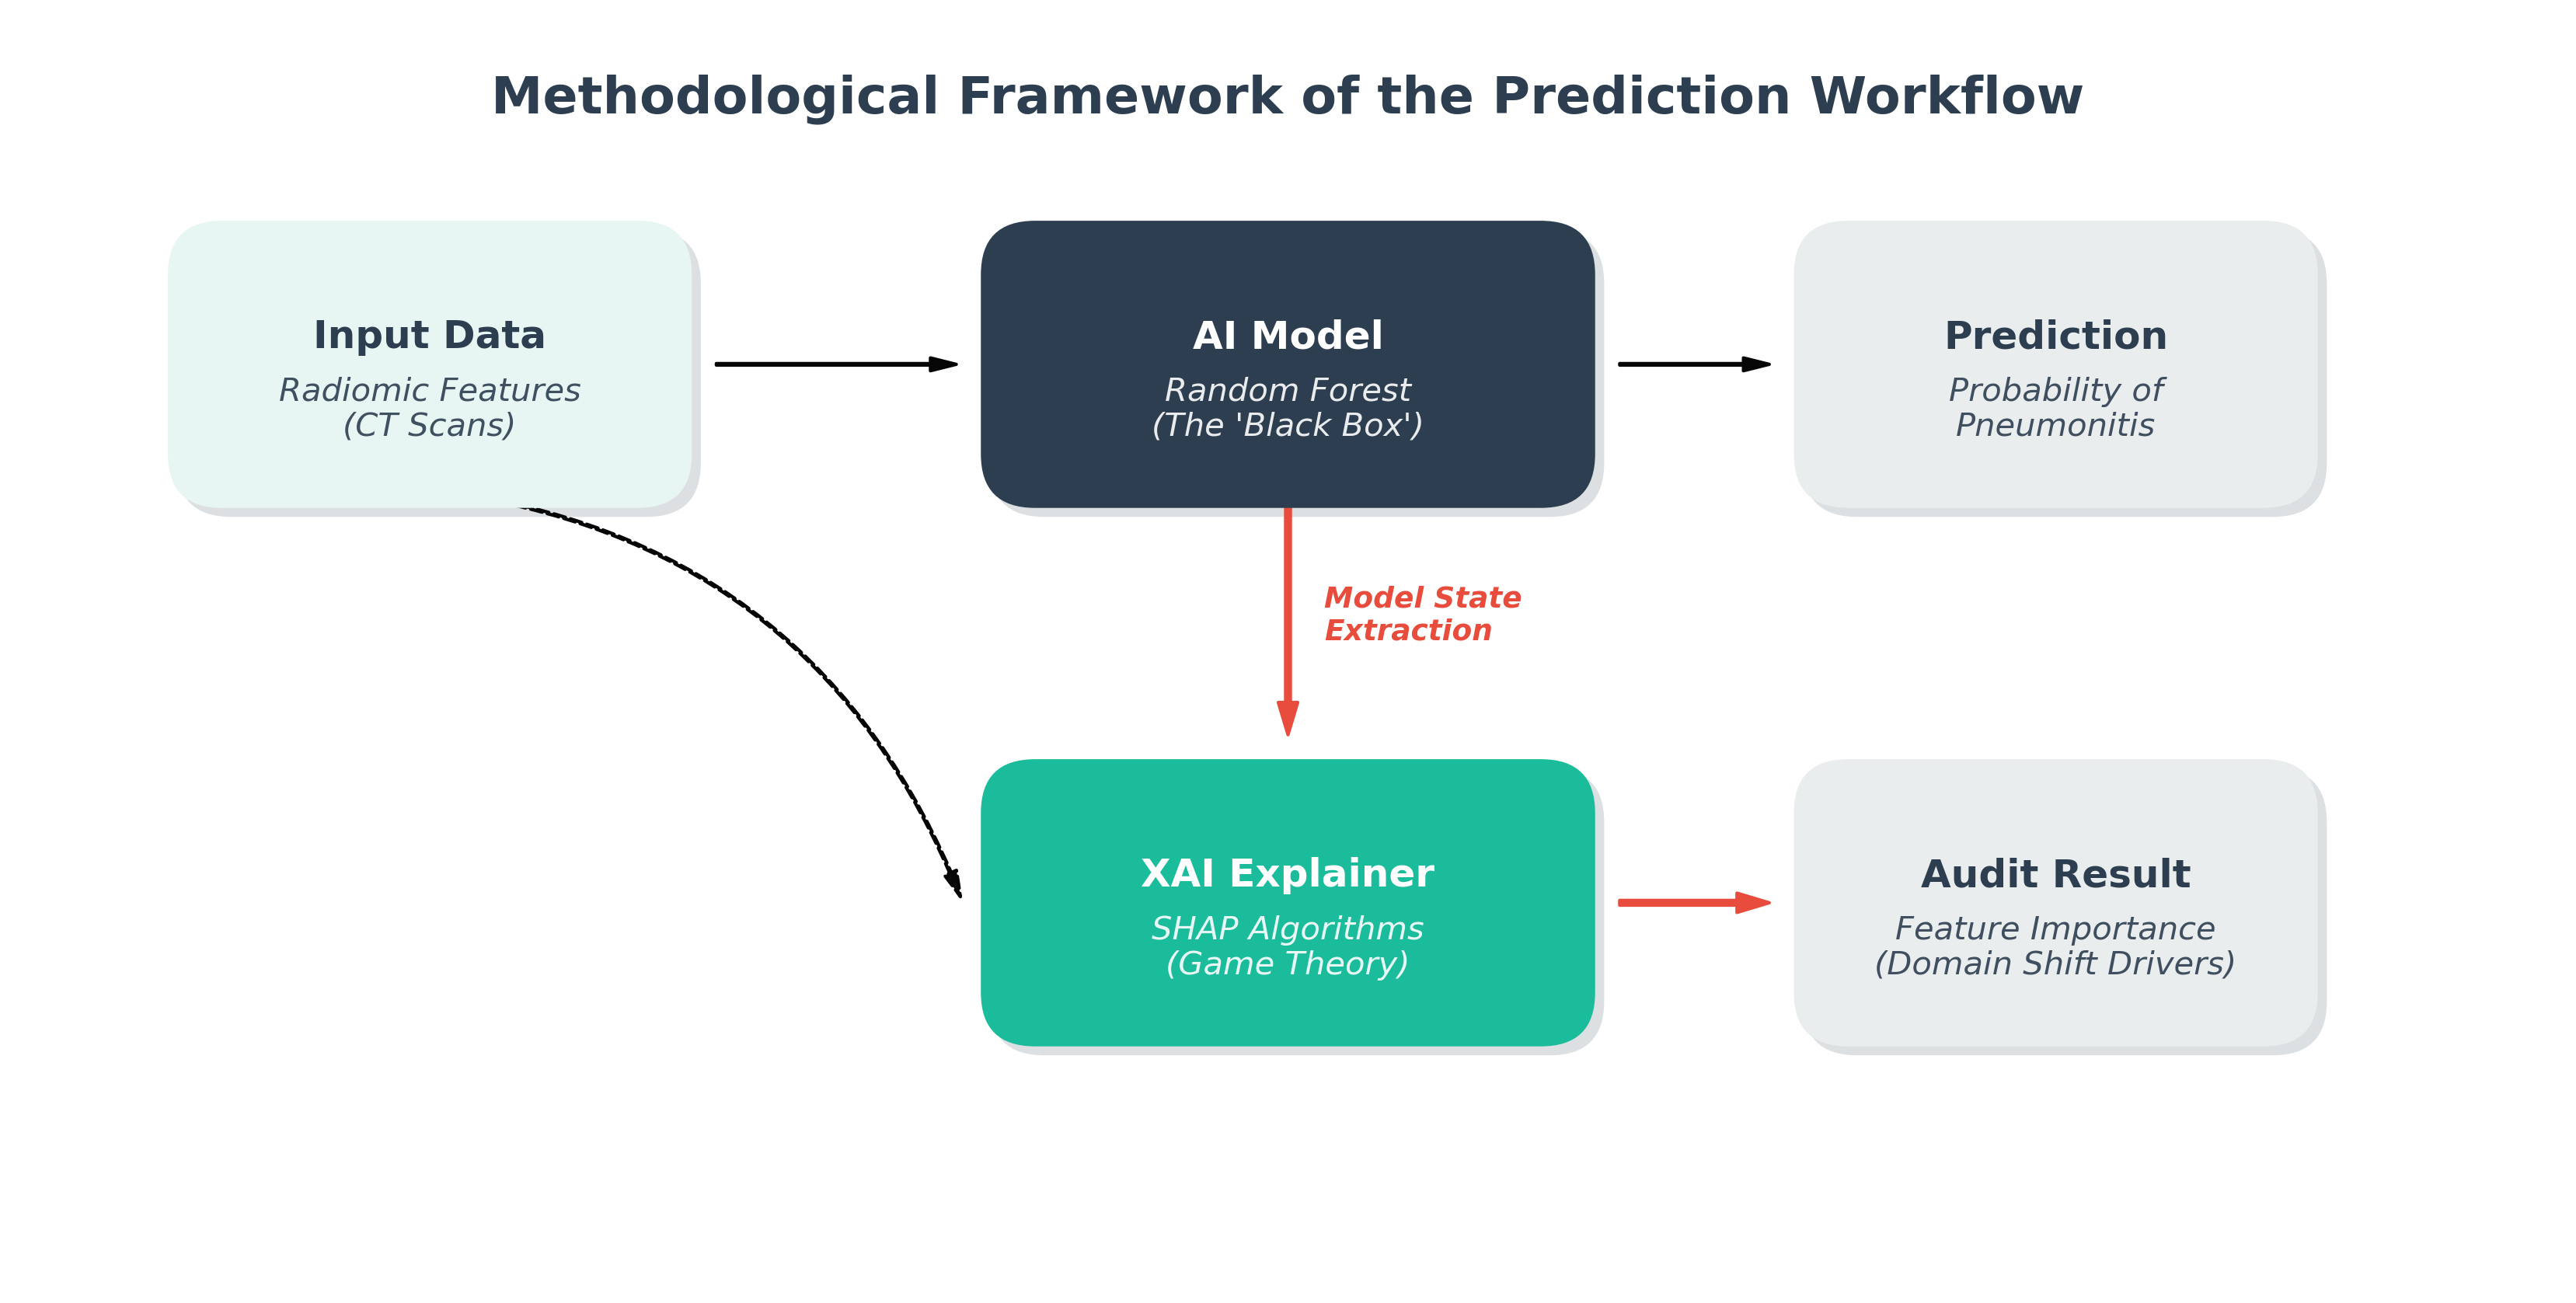

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

# --- CONFIGURATION ---
output_dir = '../Results/Final_Figures/'
import os
os.makedirs(output_dir, exist_ok=True)

def draw_modern_schematic():
    # 1. Setup Canvas (High Res, Wide Aspect)
    fig, ax = plt.subplots(figsize=(14, 7), dpi=300)
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 7)
    ax.axis('off') # Hide the coordinate system

    # --- MODERN COLOR PALETTE ---
    # Slate (Dark) for structure, Teal/Coral for emphasis
    colors = {
        'input':   '#E8F6F3', # Very light teal
        'model':   '#2C3E50', # Dark Slate (The "Black Box")
        'shap':    '#1ABC9C', # Vibrant Teal (The "Solution")
        'output':  '#EAEDED', # Light Gray
        'audit':   '#E74C3C', # Coral Red (The "Audit Path")
        'text_dark': '#2C3E50',
        'text_light': '#FFFFFF'
    }

    # --- HELPER: DRAW ROUNDED BOX ---
    def draw_node(x, y, width, height, color, label, sublabel, text_color):
        # Shadow (for depth)
        shadow = FancyBboxPatch((x+0.05, y-0.05), width, height,
                                boxstyle="round,pad=0.2,rounding_size=0.3",
                                ec="none", fc="#bdc3c7", alpha=0.5, zorder=1)
        ax.add_patch(shadow)
        
        # Main Box
        box = FancyBboxPatch((x, y), width, height,
                             boxstyle="round,pad=0.2,rounding_size=0.3",
                             ec="none", fc=color, zorder=2)
        ax.add_patch(box)
        
        # Text
        cx = x + width/2
        cy = y + height/2
        ax.text(cx, cy + 0.15, label, ha="center", va="center", 
                size=12, fontweight='bold', color=text_color, zorder=3)
        ax.text(cx, cy - 0.25, sublabel, ha="center", va="center", 
                size=10, style='italic', color=text_color, zorder=3, alpha=0.9)

    # --- DRAW NODES ---
    
    # 1. Input Data (Left)
    draw_node(1.0, 4.5, 2.5, 1.2, colors['input'], "Input Data", "Radiomic Features\n(CT Scans)", colors['text_dark'])
    
    # 2. The Black Box Model (Top Center)
    draw_node(5.5, 4.5, 3.0, 1.2, colors['model'], "AI Model", "Random Forest\n(The 'Black Box')", colors['text_light'])
    
    # 3. The SHAP Explainer (Bottom Center - The Hero)
    draw_node(5.5, 1.5, 3.0, 1.2, colors['shap'], "XAI Explainer", "SHAP Algorithms\n(Game Theory)", colors['text_light'])
    
    # 4. Prediction Output (Top Right)
    draw_node(10.0, 4.5, 2.5, 1.2, colors['output'], "Prediction", "Probability of\nPneumonitis", colors['text_dark'])
    
    # 5. Insight Output (Bottom Right)
    draw_node(10.0, 1.5, 2.5, 1.2, colors['output'], "Audit Result", "Feature Importance\n(Domain Shift Drivers)", colors['text_dark'])

    # --- DRAW CONNECTORS (Modern Curved Arrows) ---
    
    style_standard = "Simple, tail_width=0.5, head_width=4, head_length=8"
    style_audit = "Simple, tail_width=1.5, head_width=6, head_length=10" # Thicker
    
    # A. Standard Path (Top)
    # Input -> Model
    arrow1 = mpatches.FancyArrowPatch((3.8, 5.1), (5.2, 5.1), connectionstyle="arc3,rad=0", 
                                      arrowstyle=style_standard, color="#060606", zorder=1)
    # Model -> Prediction
    arrow2 = mpatches.FancyArrowPatch((8.8, 5.1), (9.7, 5.1), connectionstyle="arc3,rad=0", 
                                      arrowstyle=style_standard, color="#060606", zorder=1)
    
    # B. The Audit Path (The Thesis Focus)
    # Input -> Explainer (Curved down)
    arrow3 = mpatches.FancyArrowPatch((2.25, 4.4), (5.2, 2.1), connectionstyle="arc3,rad=-0.3", 
                                      arrowstyle=style_standard, color="#060606", ls="--", zorder=1)
    
    # Model -> Explainer (Straight Down - The "Extraction")
    arrow4 = mpatches.FancyArrowPatch((7.0, 4.4), (7.0, 3.0), connectionstyle="arc3,rad=0", 
                                      arrowstyle=style_audit, color=colors['audit'], zorder=1)
    
    # Explainer -> Interpretation (Right)
    arrow5 = mpatches.FancyArrowPatch((8.8, 2.1), (9.7, 2.1), connectionstyle="arc3,rad=0", 
                                      arrowstyle=style_audit, color=colors['audit'], zorder=1)

    ax.add_patch(arrow1)
    ax.add_patch(arrow2)
    ax.add_patch(arrow3)
    ax.add_patch(arrow4)
    ax.add_patch(arrow5)

    # --- ANNOTATIONS ---
    
    # Label the Paths
#     ax.text(7.0, 5.8, "Standard Prediction Workflow", ha="center", size=10, color="#7f8c8d", weight="bold")
#     ax.text(7.0, 0.8, "XAI Audit Workflow (Thesis Contribution)", ha="center", size=10, color=colors['audit'], weight="bold")
    
    # Label the Extraction Arrow
    ax.text(7.2, 3.7, "Model State\nExtraction", ha="left", va="center",weight= 'bold', size=9, color=colors['audit'], style='italic')

    # Title
    plt.text(7.0, 6.5, "Methodological Framework of the Prediction Workflow", 
             ha="center", size=16, weight='bold', color=colors['text_dark'])

    # Save
    save_path = f"{output_dir}Figure_3_Modern_XAI_Schematic.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Modern Schematic Saved: {save_path}")
    plt.show()

draw_modern_schematic()

In [4]:
import pandas as pd
import numpy as np
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import os

# --- CONFIGURATION ---
radiomics_file = '../Results/final_radiomics_merged.csv' 
output_dir = '../Results/Final_Figures/'
os.makedirs(output_dir, exist_ok=True)

# Set template
pio.templates.default = "plotly_white"

print("--- STARTING MODERN XAI AUDIT (FIXED FONTS + WATERFALL) ---")

# 1. Load Data
try:
    df_rad = pd.read_csv(radiomics_file)
    
    # 2. Prepare Target
    cohorts = df_rad['Cohort'].unique()
    target_map = {c: 1 if 'Local' in c else 0 for c in cohorts}
    df_rad['Target'] = df_rad['Cohort'].map(target_map)
    
    label_0 = [k for k,v in target_map.items() if v==0][0]
    label_1 = [k for k,v in target_map.items() if v==1][0]
    
    # Features
    feature_cols = [c for c in df_rad.columns if 'original_' in c]
    X = df_rad[feature_cols].fillna(0)
    y = df_rad['Target']
    
    # Clean Names
    clean_names = []
    for col in X.columns:
        name = col.replace('original_', '').replace('wavelet_', '').replace('glcm_', 'Texture: ').replace('shape_', 'Shape: ').replace('firstorder_', 'Stats: ')
        if len(name) > 45: name = name[:42] + "..." 
        clean_names.append(name)
    
    X.columns = clean_names
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # 3. Train Model
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # Validation
    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, y_pred)
    print(f"AUC Score: {auc:.4f}")
    
    # 4. SHAP Analysis
    print("Calculating SHAP...")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    
    if isinstance(shap_values, list):
        vals = shap_values[1]
        base_val = explainer.expected_value[1]
    else:
        if len(shap_values.shape) == 3: vals = shap_values[:, :, 1]
        else: vals = shap_values
        base_val = explainer.expected_value

    # --- 5. BEESWARM SUMMARY PLOT ---
    print("Generating Beeswarm Plot...")
    
    mean_abs_shap = np.abs(vals).mean(axis=0)
    sorted_idx = np.argsort(mean_abs_shap)[-15:] 
    
    plot_data = []
    for i in sorted_idx:
        feature_name = X_test.columns[i]
        shap_val = vals[:, i]
        feature_val = X_test.iloc[:, i].values
        
        denominator = feature_val.max() - feature_val.min()
        if denominator > 0:
            norm_val = (feature_val - feature_val.min()) / denominator
        else:
            norm_val = np.zeros_like(feature_val)
        
        jitter = np.random.normal(0, 0.1, size=len(shap_val)) 
        
        for sv, nv, fv, jit in zip(shap_val, norm_val, feature_val, jitter):
            plot_data.append({
                'Feature': feature_name,
                'SHAP Value': float(sv),
                'Normalized Value': float(nv),
                'Raw Value': float(fv),
                'Y_Position': i + jit 
            })
            
    df_plot = pd.DataFrame(plot_data)
    
    fig = px.scatter(
        df_plot, 
        x='SHAP Value', 
        y='Y_Position', 
        color='Normalized Value',
        color_continuous_scale='RdBu_r', 
        hover_data=['Feature', 'Raw Value'],
        title=f"<b>XAI Audit: Population View</b><br><sup>What distinguishes {label_1} from {label_0}?</sup>"
    )
    
    sorted_features = [X_test.columns[i] for i in sorted_idx]
    
    fig.update_layout(
        width=1000,
        height=800,
        margin=dict(l=300, t=100), 
        font=dict(size=12),
        coloraxis_colorbar=dict(title="Feature Value<br>(Red=High, Blue=Low)"),
        yaxis=dict(
            title="",
            tickmode='array',
            tickvals=list(range(len(sorted_features))),
            ticktext=sorted_features,
            tickfont=dict(size=10) 
        )
    )
    
    fig.add_vline(x=0, line_width=1, line_dash="dash", line_color="black")
    
    fig.write_html(f"{output_dir}Figure_XAI_Beeswarm.html")
    try:
        fig.write_image(f"{output_dir}Figure_4.4_SHAP_Summary.png", scale=3)
        print("  -> Saved Beeswarm PNG")
    except: pass
    
    # --- 6. WATERFALL PLOT (Individual Patient) ---
    print("Generating Waterfall Plot...")
    
    # Select first patient in test set
    pat_idx = 0
    patient_shap = vals[pat_idx]
    patient_data = X_test.iloc[pat_idx]
    
    # Get top 10 contributing features for this patient
    # Sort by absolute SHAP impact
    impact_order = np.argsort(np.abs(patient_shap))[-10:]
    
    wf_names = X_test.columns[impact_order]
    wf_values = patient_shap[impact_order]
    wf_data_values = patient_data.iloc[impact_order]
    
    # Create Waterfall
    fig_wf = go.Figure(go.Waterfall(
        name = "SHAP",
        orientation = "h",
        measure = ["relative"] * len(wf_names),
        y = wf_names,
        x = wf_values,
        connector = {"mode":"between", "line":{"width":4, "color":"rgb(0, 0, 0)", "dash":"solid"}},
        decreasing = {"marker":{"color":"#3498db"}}, # Blue for negative
        increasing = {"marker":{"color":"#e74c3c"}}, # Red for positive
        text = [f"{v:.2f}" for v in wf_values],
        textposition = "outside"
    ))

    fig_wf.update_layout(
        title = f"<b>XAI Audit: Patient Case Study</b><br><sup>Why was this patient classified as {label_1 if y_pred[pat_idx]==1 else label_0}?</sup>",
        showlegend = False,
        width=900,
        height=600,
        margin=dict(l=250),
        xaxis=dict(title="SHAP Value (Contribution to Score)"),
        yaxis=dict(title="", tickfont=dict(size=10))
    )
    
    fig_wf.write_html(f"{output_dir}Figure_XAI_Waterfall.html")
    try:
        fig_wf.write_image(f"{output_dir}Figure_4.5_SHAP_Waterfall.png", scale=3)
        print("  -> Saved Waterfall PNG")
    except: pass
    
    # fig.show() # Commented out to prevent double plot in some notebooks
    # fig_wf.show()

except Exception as e:
    import traceback
    print(f"Error: {e}")
    traceback.print_exc()

--- STARTING MODERN XAI AUDIT (FIXED FONTS + WATERFALL) ---
AUC Score: 1.0000
Calculating SHAP...
Generating Beeswarm Plot...
  -> Saved Beeswarm PNG
Generating Waterfall Plot...
  -> Saved Waterfall PNG


Training Model...
Calculating SHAP...
Generating Plot...
SUCCESS: Saved Beeswarm plot to ../Results/Final_Figures/Figure_4.4_SHAP_Beeswarm.png


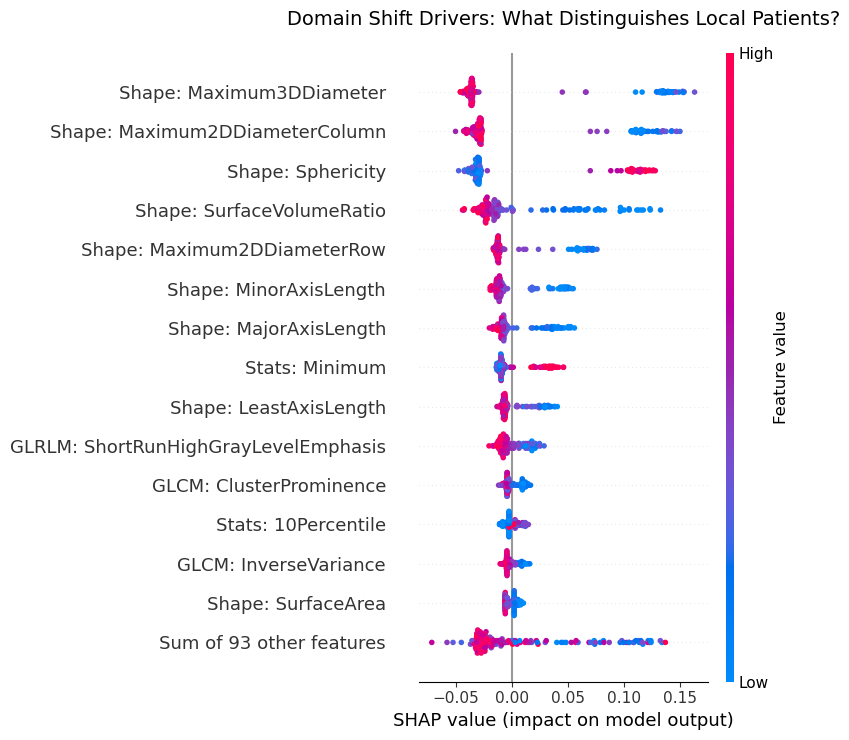

In [5]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import os

# --- CONFIGURATION ---
radiomics_file = '../Results/final_radiomics_merged.csv' 
output_dir = '../Results/Final_Figures/'
os.makedirs(output_dir, exist_ok=True)

# --- CLEANER FUNCTION (Shortens names for the plot) ---
def clean_radiomics_name_short(name):
    name = name.replace('original_', '')
    mappings = {
        'shape_': 'Shape', 'firstorder_': 'Stats', # Shortened 'Intensity' to 'Stats'
        'glcm_': 'GLCM', 'glrlm_': 'GLRLM',
        'glszm_': 'GLSZM', 'gldm_': 'GLDM',
        'ngtdm_': 'NGTDM'
    }
    metric = name
    category = ""
    for key, val in mappings.items():
        if key in name:
            category = val
            metric = name.replace(key, '')
            break
    
    # Capitalize metric
    metric = metric[0].upper() + metric[1:] if len(metric) > 0 else metric
    
    # Return compact format: "GLCM: Contrast"
    if category:
        return f"{category}: {metric}"
    return metric

# --- LOAD DATA ---
df_rad = pd.read_csv(radiomics_file)
cohorts = df_rad['Cohort'].unique()
target_map = {c: 1 if 'Local' in c else 0 for c in cohorts}
df_rad['Target'] = df_rad['Cohort'].map(target_map)

feature_cols = [c for c in df_rad.columns if 'original_' in c]
X = df_rad[feature_cols].fillna(0)
y = df_rad['Target']

# Apply Clean Short Names
X.columns = [clean_radiomics_name_short(c) for c in X.columns]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- TRAIN MODEL ---
print("Training Model...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# --- CALCULATE SHAP ---
print("Calculating SHAP...")
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test) # Using the modern 'explainer' call

# The shap_values object contains data for both classes.
# We focus on the 'Local Cohort' (Class 1)
shap_values_class1 = shap_values[:, :, 1]

# --- GENERATE & SAVE BEESWARM PLOT ---
print("Generating Plot...")

plt.figure(figsize=(12, 8)) # Large canvas

# The Magic Line: adjust the max_display to show top features
shap.plots.beeswarm(shap_values_class1, max_display=15, show=False)

# Customizing the layout
plt.title("Domain Shift Drivers: What Distinguishes Local Patients?", fontsize=14, pad=20)
plt.tight_layout()

# Save
save_path = f"{output_dir}Figure_4.4_SHAP_Beeswarm.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"SUCCESS: Saved Beeswarm plot to {save_path}")

# Show it
plt.show()

Loading Data...
Training AI Model...
Calculating SHAP Values...
DONE. Image saved to: ../Results/Final_Figures/Figure_4.4_SHAP_Final_Fixed.png


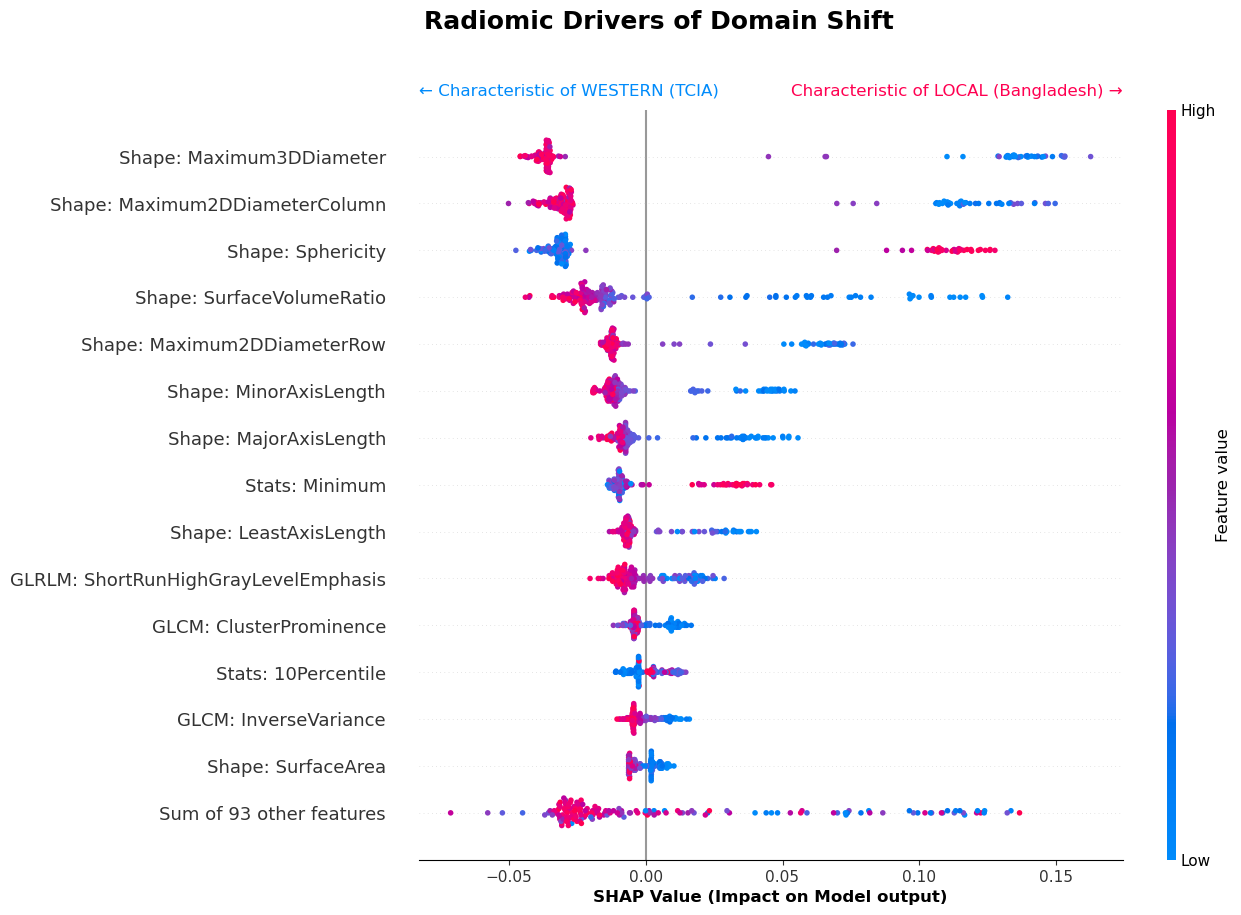

In [9]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import os

# --- CONFIGURATION ---
radiomics_file = '../Results/final_radiomics_merged.csv' 
output_dir = '../Results/Final_Figures/'
os.makedirs(output_dir, exist_ok=True)

# --- 1. SMART NAME CLEANER (Keeps them short but readable) ---
def clean_radiomics_name_smart(name):
    # Remove technical garbage
    name = name.replace('original_', '').replace('log-sigma-1-0-mm-3D_', '')
    
    # Map to clear English
    mappings = {
        'shape_': 'Shape', 
        'firstorder_': 'Stats', 
        'glcm_': 'GLCM', 
        'glrlm_': 'GLRLM',
        'glszm_': 'GLSZM', 
        'gldm_': 'GLDM',
        'ngtdm_': 'NGTDM'
    }
    
    category = ""
    metric = name
    for key, val in mappings.items():
        if key in name:
            category = val
            metric = name.replace(key, '')
            break
            
    # Capitalize and format
    metric = metric[0].upper() + metric[1:] if len(metric) > 0 else metric
    
    # Return formatted string (e.g., "GLCM: Contrast")
    if category:
        return f"{category}: {metric}"
    return metric

# --- 2. LOAD & PREP DATA ---
print("Loading Data...")
df_rad = pd.read_csv(radiomics_file)
cohorts = df_rad['Cohort'].unique()
target_map = {c: 1 if 'Local' in c else 0 for c in cohorts}
df_rad['Target'] = df_rad['Cohort'].map(target_map)

# Select & Clean Features
feature_cols = [c for c in df_rad.columns if 'original_' in c]
X = df_rad[feature_cols].fillna(0)
y = df_rad['Target']
X.columns = [clean_radiomics_name_smart(c) for c in X.columns] # Apply cleaner

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- 3. TRAIN & CALCULATE SHAP ---
print("Training AI Model...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Calculating SHAP Values...")
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)
shap_values_local = shap_values[:, :, 1] # Focus on Local Cohort (Class 1)

# --- 4. THE "TOP 1%" VISUALIZATION ---
# Create a massive canvas (16x10 inches)
fig = plt.figure(figsize=(16, 10)) 

# A. The Beeswarm Plot
# We hide the color bar first (color_bar=False) to customize it later if needed, 
# but usually default is fine. We set show=False to keep control.
shap.plots.beeswarm(shap_values_local, max_display=15, show=False, plot_size=None)

# B. THE GEOMETRY FIX (Crucial Step)
# This reserves 35% of the left side for your long text labels.
plt.subplots_adjust(left=0.35, right=0.9, top=0.85, bottom=0.1)

# C. Get the axes to draw our custom signs
ax = plt.gca()

# Improve Label Readability
ax.tick_params(axis='y', labelsize=13) # Make text bigger
ax.set_xlabel("SHAP Value (Impact on Model output)", fontsize=12, fontweight='bold')

# D. Add the "Western vs Local" Signs
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

# Western Arrow (Top Left)
plt.text(xmin, ymax*1.02, "← Characteristic of WESTERN (TCIA)", 
         fontsize=12, fontweight='light', color='#008bfb', ha='left')

# Local Arrow (Top Right)
plt.text(xmax, ymax*1.02, "Characteristic of LOCAL (Bangladesh) →", 
         fontsize=12, fontweight='light', color='#ff0051', ha='right')

# E. Title and Save
plt.suptitle("Radiomic Drivers of Domain Shift", fontsize=18, fontweight='bold', y=0.95)

# Save as High-Res
save_path = f"{output_dir}Figure_4.4_SHAP_Final_Fixed.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight') # 'bbox_inches' trims extra white space

print(f"DONE. Image saved to: {save_path}")
plt.show()

In [1]:
import pandas as pd
import numpy as np
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import os

# --- CONFIGURATION ---
# We use the merged file (Public vs Square)
radiomics_file = '../Results/final_radiomics_merged.csv' 
output_dir = '../Results/Final_Figures/'
os.makedirs(output_dir, exist_ok=True)

# Set template
pio.templates.default = "plotly_white"

print("--- STARTING MODERN XAI AUDIT (DOCTOR-FRIENDLY) ---")

# 1. Load Data
try:
    df_rad = pd.read_csv(radiomics_file)
    print(f"Data Loaded: {len(df_rad)} patients")
    
    # 2. Prepare Target
    # 0 = Public (Western), 1 = Local (Square)
    cohorts = df_rad['Cohort'].unique()
    target_map = {c: 1 if 'Local' in c else 0 for c in cohorts}
    df_rad['Target'] = df_rad['Cohort'].map(target_map)
    
    label_0 = [k for k,v in target_map.items() if v==0][0]
    label_1 = [k for k,v in target_map.items() if v==1][0]
    
    # Features: Only radiomics
    feature_cols = [c for c in df_rad.columns if 'original_' in c]
    X = df_rad[feature_cols].fillna(0)
    y = df_rad['Target']
    
    # --- STEP 3: CLEAN NAMES FOR DOCTORS ---
    clean_names = []
    for col in X.columns:
        # Remove prefixes
        name = col.replace('original_', '').replace('wavelet_', '')
        # Add Categories
        if 'glcm' in name: name = name.replace('glcm_', 'Texture: ')
        elif 'glrlm' in name: name = name.replace('glrlm_', 'Texture: ')
        elif 'gldm' in name: name = name.replace('gldm_', 'Texture: ')
        elif 'glszm' in name: name = name.replace('glszm_', 'Texture: ')
        elif 'shape' in name: name = name.replace('shape_', 'Shape: ')
        elif 'firstorder' in name: name = name.replace('firstorder_', 'Stats: ')
        
        # Truncate if insanely long
        if len(name) > 40: name = name[:37] + "..."
        clean_names.append(name)
    
    X.columns = clean_names # Apply new names
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # 4. Train Model
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, y_pred)
    print(f"AUC Score: {auc:.4f} (Ability to distinguish {label_1} from {label_0})")
    
    # 5. SHAP Analysis
    print("Calculating SHAP Values...")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    
    if isinstance(shap_values, list):
        vals = shap_values[1]
    else:
        if len(shap_values.shape) == 3: vals = shap_values[:, :, 1]
        else: vals = shap_values

    # --- PLOT 1: FEATURE IMPORTANCE (BAR) ---
    print("Generating Importance Plot...")
    mean_abs_shap = np.abs(vals).mean(axis=0)
    sorted_idx = np.argsort(mean_abs_shap)[-10:] # Top 10
    
    fig_bar = px.bar(
        x=mean_abs_shap[sorted_idx],
        y=X_test.columns[sorted_idx],
        orientation='h',
        title=f"<b>Top 10 Drivers of Domain Shift</b>",
        labels={'x': "Average Impact on Model Decision", 'y': "Radiomic Feature"},
        color_discrete_sequence=['#3498db']
    )
    fig_bar.update_layout(height=500, width=800, margin=dict(l=200)) # Margin fixes overlap
    fig_bar.show()
    fig_bar.write_image(f"{output_dir}Figure_4.5_SHAP_Importance.png", scale=3)

    # --- PLOT 2: BEESWARM SUMMARY (MANUAL PLOTLY) ---
    print("Generating Summary Plot...")
    
    # Prepare data for top 12 features
    top_idx = np.argsort(mean_abs_shap)[-12:]
    
    plot_data = []
    for i in top_idx:
        fname = X_test.columns[i]
        shap_val = vals[:, i]
        raw_val = X_test.iloc[:, i].values
        
        # Normalize for color (0-1)
        norm_val = (raw_val - raw_val.min()) / (raw_val.max() - raw_val.min() + 1e-9)
        
        # Jitter for beeswarm effect
        jitter = np.random.normal(0, 0.12, size=len(shap_val))
        
        for sv, nv, fv, jit in zip(shap_val, norm_val, raw_val, jitter):
            plot_data.append({
                'Feature': fname,
                'SHAP': sv,
                'ColorVal': nv,
                'Raw': fv,
                'Y_Pos': i + jit
            })
            
    df_plot = pd.DataFrame(plot_data)
    
    # Get sorted feature names for Y-axis
    sorted_names = [X_test.columns[i] for i in top_idx]

    fig_bee = px.scatter(
        df_plot, x='SHAP', y='Y_Pos', color='ColorVal',
        color_continuous_scale='RdBu_r', # Red=High, Blue=Low
        hover_data=['Feature', 'Raw'],
        title=f"<b>XAI Audit: Why are they different?</b><br><sup>Feature values pushing model towards '{label_1}' (Right) or '{label_0}' (Left)</sup>"
    )
    
    fig_bee.update_layout(
        height=700, width=1000,
        margin=dict(l=300), # HUGE Left Margin for Long Names
        yaxis=dict(
            title="",
            tickmode='array',
            tickvals=list(range(len(sorted_names))),
            ticktext=sorted_names,
            tickfont=dict(size=11) # Readable Font
        ),
        coloraxis_colorbar=dict(title="Feature Value<br>(Red=High, Blue=Low)")
    )
    fig_bee.add_vline(x=0, line_dash="dash", line_color="black")
    fig_bee.show()
    fig_bee.write_image(f"{output_dir}Figure_4.4_SHAP_Summary.png", scale=3)

    # --- PLOT 3: WATERFALL (PATIENT CASE STUDY) ---
    print("Generating Patient Case Study...")
    
    # Pick a random "Local" patient to explain
    local_indices = np.where(y_test.values == 1)[0]
    if len(local_indices) > 0:
        pat_idx = local_indices[0] # First local patient
        patient_shap = vals[pat_idx]
        patient_data = X_test.iloc[pat_idx]
        
        # Top 10 factors for this specific patient
        impact_idx = np.argsort(np.abs(patient_shap))[-10:]
        
        fig_water = go.Figure(go.Waterfall(
            name = "SHAP", orientation = "h",
            measure = ["relative"] * 10,
            y = X_test.columns[impact_idx],
            x = patient_shap[impact_idx],
            connector = {"mode":"between", "line":{"width":4, "color":"rgb(0,0,0)", "dash":"solid"}},
            decreasing = {"marker":{"color":"#3498db"}},
            increasing = {"marker":{"color":"#e74c3c"}}
        ))
        
        fig_water.update_layout(
            title = f"<b>Patient Case Study:</b> Why was this scan flagged as '{label_1}'?",
            height=600, width=900,
            margin=dict(l=250),
            yaxis=dict(tickfont=dict(size=11))
        )
        fig_water.show()
        fig_water.write_image(f"{output_dir}Figure_4.6_Patient_Case.png", scale=3)

    print("\nAll XAI plots saved successfully.")
    
except Exception as e:
    import traceback
    print(f"Error: {e}")
    traceback.print_exc()

d:\Anaconda\envs\thesis_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- STARTING MODERN XAI AUDIT (DOCTOR-FRIENDLY) ---
Data Loaded: 542 patients
AUC Score: 1.0000 (Ability to distinguish Local (Bangladesh) from Public (Western))
Calculating SHAP Values...
Generating Importance Plot...


Generating Summary Plot...


Generating Patient Case Study...



All XAI plots saved successfully.
